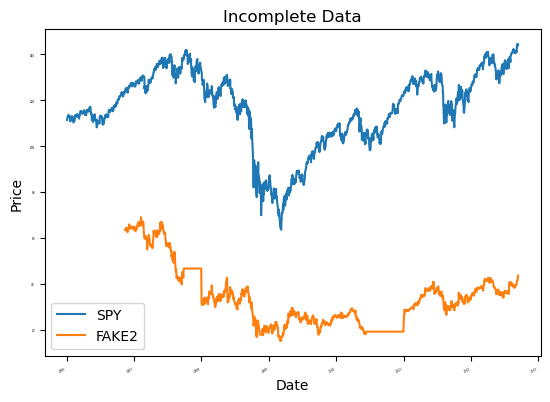

In [12]:
"""Using Fillna()"""

import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

#----------function to get path of the symbol-------------
def symbol_to_path(symbol, base_dir="../data"):
	"""Return CSV file path given ticker symbol."""
	return os.path.join(base_dir, "{}.csv".format(str(symbol)))

#--------------------Reads csv----------------------------
def get_data(symbollist, dates):
	df_final=pd.DataFrame(index=dates)
	if "SPY" not in symbollist:
		symbollist.insert(0,"SPY")
	for symbol in symbollist:
		file_path=symbol_to_path(symbol)
		df_temp=pd.read_csv(file_path, parse_dates=True, index_col="Date",usecols=["Date", "Adj Close"], na_values=["nan"])
		df_temp=df_temp.rename(columns={'Adj Close':symbol})
		df_final=df_final.join(df_temp)
		if symbol == "SPY":
			df_final=df_final.dropna(subset=['SPY'])
	return df_final

#--------------------plot function-------------------------
def plot(df_data):
	ax=df_data.plot(title="Incomplete Data", fontsize=2)
	ax.set_xlabel("Date")
	ax.set_ylabel("Price")
	plt.show()


#list of symbols
#symbollist=["PSX", "FAKE1", "FAKE2"]
symbollist=["FAKE2"]
#date range
start_date='2005-12-31'
end_date='2014-12-07'
#create date range
idx=pd.date_range(start_date,end_date)
#get adjusted close of each symbol
df_data=get_data(symbollist,idx)
df_data.ffill(inplace=True)
plot(df_data)


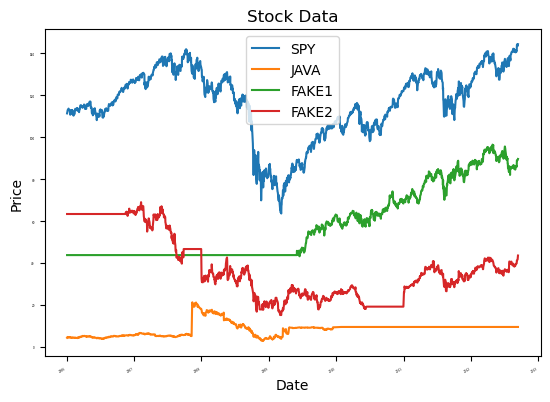

In [14]:
"""Fill missing values"""

def fill_missing_values(df_data):
    """Fill missing values in data frame, in place."""
    ##########################################################
    pass  # QUIZ: Your code here (DO NOT modify anything else)
    df_data.ffill(inplace=True)
    df_data.bfill(inplace=True)
    ##########################################################

def symbol_to_path(symbol, base_dir="../data"):
    """Return CSV file path given ticker symbol."""
    return os.path.join(base_dir, "{}.csv".format(str(symbol)))

def get_data(symbols, dates):
    """Read stock data (adjusted close) for given symbols from CSV files."""
    df_final = pd.DataFrame(index=dates)
    if "SPY" not in symbols:  # add SPY for reference, if absent
        symbols.insert(0, "SPY")

    for symbol in symbols:
        file_path = symbol_to_path(symbol)
        df_temp = pd.read_csv(file_path, parse_dates=True, index_col="Date",
            usecols=["Date", "Adj Close"], na_values=["nan"])
        df_temp = df_temp.rename(columns={"Adj Close": symbol})
        df_final = df_final.join(df_temp)
        if symbol == "SPY":  # drop dates SPY did not trade
            df_final = df_final.dropna(subset=["SPY"])

    return df_final

def plot_data(df_data):
    """Plot stock data with appropriate axis labels."""
    ax = df_data.plot(title="Stock Data", fontsize=2)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    plt.show()

def test_run():
    """Function called by Test Run."""
    # Read data
    symbol_list = ["JAVA", "FAKE1", "FAKE2"]  # list of symbols
    start_date = "2005-12-31"
    end_date = "2014-12-07"
    dates = pd.date_range(start_date, end_date)  # date range as index
    df_data = get_data(symbol_list, dates)  # get data for each symbol

    # Fill missing values
    fill_missing_values(df_data)

    # Plot
    plot_data(df_data)

test_run()